In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf

In [30]:
# Low res
# results_dir = '/srv/scratch/z5370003/projects/results/04_groundwater/variable_density/GINO_predictions/forcing_standard_loss/resolution_1.0/gino_predictions_20260318_141229/'
# results_dir = '/srv/scratch/z5370003/projects/results/04_groundwater/variable_density/FNO_predictions/forcing/fno_predictions_20260117_134440/'

# # High res
results_dir = '/srv/scratch/z5370003/projects/results/04_groundwater/variable_density/GINO_predictions/forcing_standard_loss/gino_predictions_20260117_115735/'

# prediction files
train_preds = np.load(os.path.join(results_dir, 'train_predictions.npy'))
val_preds = np.load(os.path.join(results_dir, 'val_predictions.npy'))

# target files
train_targets = np.load(os.path.join(results_dir, 'train_targets.npy'))
val_targets = np.load(os.path.join(results_dir, 'val_targets.npy'))

# coordinate files
coords = pickle.load(open(os.path.join(results_dir, 'train_coords.pkl'), 'rb'))[0]

# Time-steps
data_dir = '/srv/scratch/z5370003/projects/data/groundwater/FEFLOW/coastal/variable_density/'
sea_level_csv_path = os.path.join(data_dir, 'SeaLevelDataPeaksHL.csv')

# load timesteps from sea level data
sea_level_data = pd.read_csv(sea_level_csv_path, names=['Time', 'SeaLevel'])
timesteps = sea_level_data['Time'].values

In [31]:
train_len = len(train_preds)

# Combine predictions
preds = np.concatenate([val_preds], axis=0)
preds = np.squeeze(preds, axis=2)
preds = np.transpose(preds, (1, 0, 2))


# Combine targets
targets = np.concatenate([val_targets], axis=0)
targets = np.squeeze(targets, axis=2)
targets = np.transpose(targets, (1, 0, 2))

# timesteps
timesteps = timesteps[train_len+10:]

# Shapes
preds.shape, targets.shape

((61360, 568, 2), (61360, 568, 2))

In [32]:
# Preds
mass_conc_preds = preds[..., 0]
hydraulic_head_preds = preds[..., 1]

# Targets
mass_conc_targets = targets[..., 0]
hydraulic_head_targets = targets[..., 1]

In [33]:
def normalize(arr):
    return (arr - np.mean(arr)) / np.std(arr)

def clip_outliers(arr):
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return np.clip(arr, lower_bound, upper_bound)

def remove_outliers(arr):
    q1 = np.percentile(arr, 25)
    q3 = np.percentile(arr, 75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    return arr[(arr >= lower_bound) & (arr <= upper_bound)], (arr >= lower_bound) & (arr <= upper_bound)

In [34]:
def add_3d_plot(fig, coords, fn, vmin, vmax, title, n, j):

    ax = fig.add_subplot(1, n, j, projection='3d')
    
    sc = ax.scatter(coords[:, 0], coords[:, 1], coords[:, 2], 
                    c=fn, cmap='viridis', vmin=vmin, vmax=vmax,
                    alpha=0.5)
    fig.colorbar(sc, label=title)
    ax.set_title(title)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    
    # Aspect Ratio
    ax.set_box_aspect((1, 1, 1.1))
    
    # View Angle
    ax.view_init(elev=45, azim=160)
    
    # Padding
    ax.xaxis.labelpad = 10
    ax.yaxis.labelpad = 10
    ax.zaxis.labelpad = 5

    return fig

In [35]:
def compute_avg_gradient(a, ts, coords, var):
    delta_a = np.diff(normalize(a), axis=1)
    delta_t = np.diff(ts)
    gradient_a = delta_a / delta_t
    avg_gradient_a = np.mean(gradient_a, axis=1)
    return avg_gradient_a


def plot_avg_gradients(ts, coords, fn_list, name_list):

    fig = plt.figure(figsize=(12, 4))

    vmin = None
    vmax = None
    
    for j in range(len(fn_list)):
        
        a = fn_list[j]
        var = name_list[j]
        
        avg_gradient_a = compute_avg_gradient(a, ts, coords, var)
        mask_a = np.ones_like(avg_gradient_a, dtype=bool)  # Placeholder for outlier mask, replace with actual mask if needed
        
        # avg_gradient_a = clip_outliers(avg_gradient_a)
        # avg_gradient_a, mask_a = remove_outliers(avg_gradient_a)

        if vmin is None:
            vmin = np.min(avg_gradient_a)
            vmax = np.max(avg_gradient_a)
            
        add_3d_plot(fig, coords[mask_a], avg_gradient_a, 
                    vmin=vmin, vmax=vmax,
                    title=f'Avg Gradient of {var}', 
                    n=len(fn_list), j=j+1)

    return fig

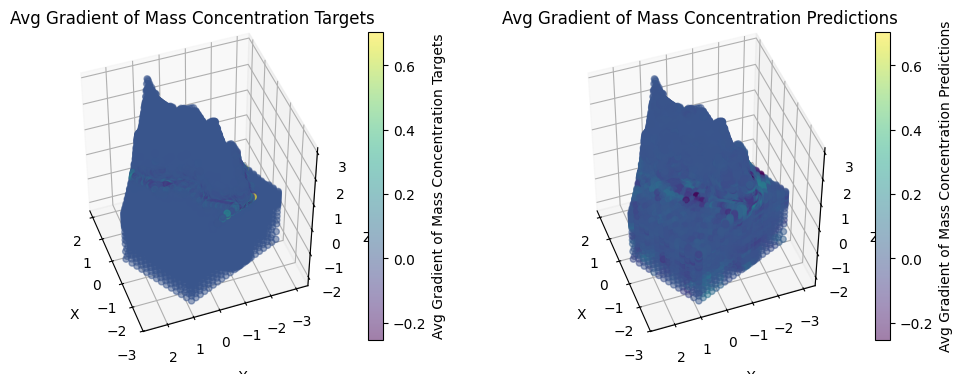

In [36]:
fig = plot_avg_gradients(timesteps, coords, [mass_conc_targets, mass_conc_preds], 
                   name_list=['Mass Concentration Targets', 'Mass Concentration Predictions'])
# fig.savefig('figures/mass_conc_low_res_gradients.png', bbox_inches='tight')

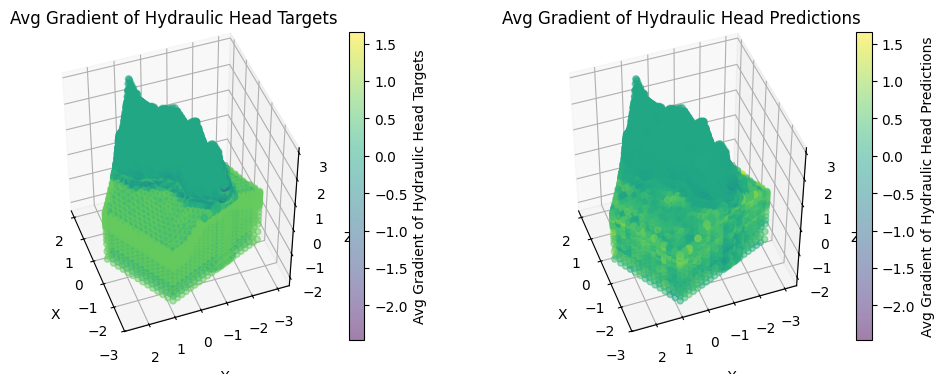

In [37]:
plot_avg_gradients(timesteps, coords, [hydraulic_head_targets, hydraulic_head_preds], 
                   name_list=['Hydraulic Head Targets', 'Hydraulic Head Predictions'])
# fig.savefig('figures/hydraulic_head_low_res_gradients.png', bbox_inches='tight')
pass

In [38]:
# plt.hist(avg_gradient_mass_conc, bins=50, alpha=0.7, label='Mass Concentration')
# plt.hist(avg_gradient_hydraulic_head, bins=50, alpha=0.7, label='Hydraulic Head')
# plt.xlabel('Average Gradient')
# plt.ylabel('Frequency')
# plt.title('Distribution of Average Gradients')
# plt.legend()
# plt.show()

## Autocorrelation

In [39]:
def compute_autocorr(a):
    autocorr = np.zeros(a.shape[0])
    for i in range(a.shape[0]): 
        autocorr[i] = np.correlate(a[i, :-1], a[i, 1:], mode='valid')[0]
    return autocorr

def plot_autocorr(ts, coords, fn_list, name_list):

    fig = plt.figure(figsize=(12, 4))

    vmin = None
    vmax = None
    
    for j in range(len(fn_list)):
        
        a = fn_list[j]
        var = name_list[j]
        
        autocorr = compute_autocorr(a)

        if vmin is None:
            vmin = np.min(autocorr)
            vmax = np.max(autocorr)
            
        add_3d_plot(fig, coords, autocorr, 
                    vmin=vmin, vmax=vmax,
                    title=f'Autocorr for {var}', 
                    n=len(fn_list), j=j+1)

    return fig

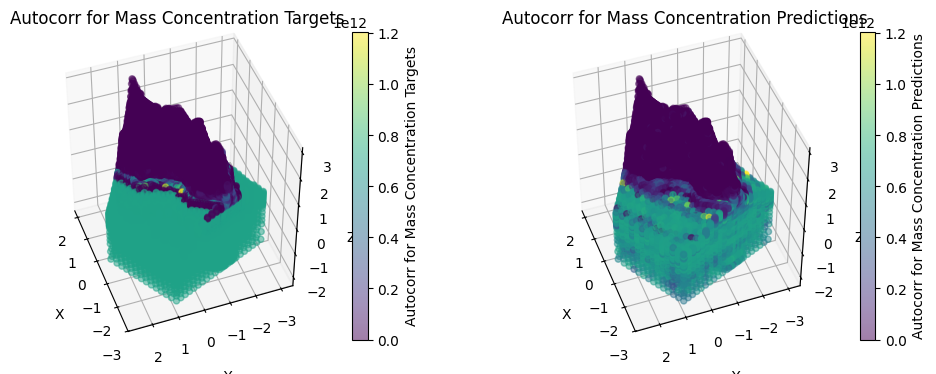

In [40]:
fig = plot_autocorr(timesteps, coords, [mass_conc_targets, mass_conc_preds], 
                   name_list=['Mass Concentration Targets', 'Mass Concentration Predictions'])
# fig.savefig('figures/mass_conc_low_res_autocorr.png', bbox_inches='tight')
pass

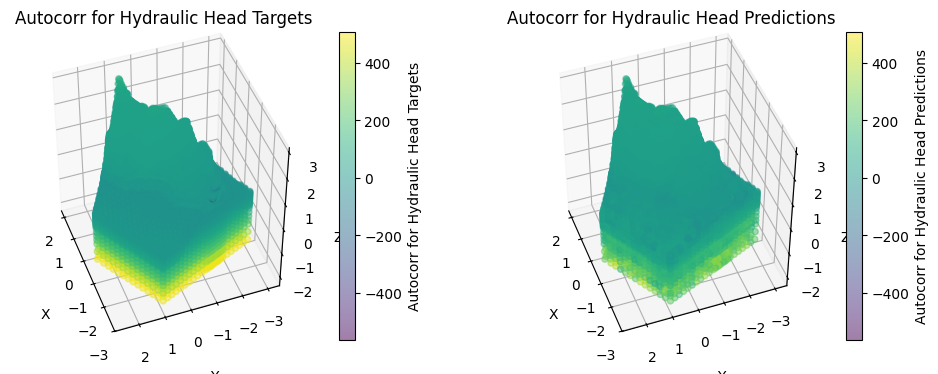

In [41]:
fig = plot_autocorr(timesteps, coords, [hydraulic_head_targets, hydraulic_head_preds], 
                   name_list=['Hydraulic Head Targets', 'Hydraulic Head Predictions'])
# fig.savefig('figures/hydraulic_head_low_res_autocorr.png', bbox_inches='tight')
pass

In [15]:
import plotly.express as px
import pandas as pd
import numpy as np

import plotly.io as pio

# Set the renderer to iframe (or iframe_connected)
pio.renderers.default = 'iframe'


autocorr = compute_autocorr(mass_conc_preds)

# 1. Combine your arrays into a Pandas DataFrame
df = pd.DataFrame({
    'x': coords[:, 0],
    'y': coords[:, 1],
    'z': coords[:, 2],
    'Autocorr for Mass Conc Targets': autocorr
})

# 2. Generate the interactive 3D scatter plot
fig = px.scatter_3d(
    df, 
    x='x', 
    y='y', 
    z='z',
    color='Autocorr for Mass Conc Targets',
    opacity=1.0,  # Adding opacity to match the translucent look of your matplotlib plot
    color_continuous_scale='viridis'  # Viridis closely matches your current colormap
)

# Optional: Adjust the marker size if they appear too large/small by default
fig.update_traces(marker=dict(size=4))

# 3. Display the interactive plot
fig.show()

Text(0, 0.5, 'Autocorrelation Coefficient')

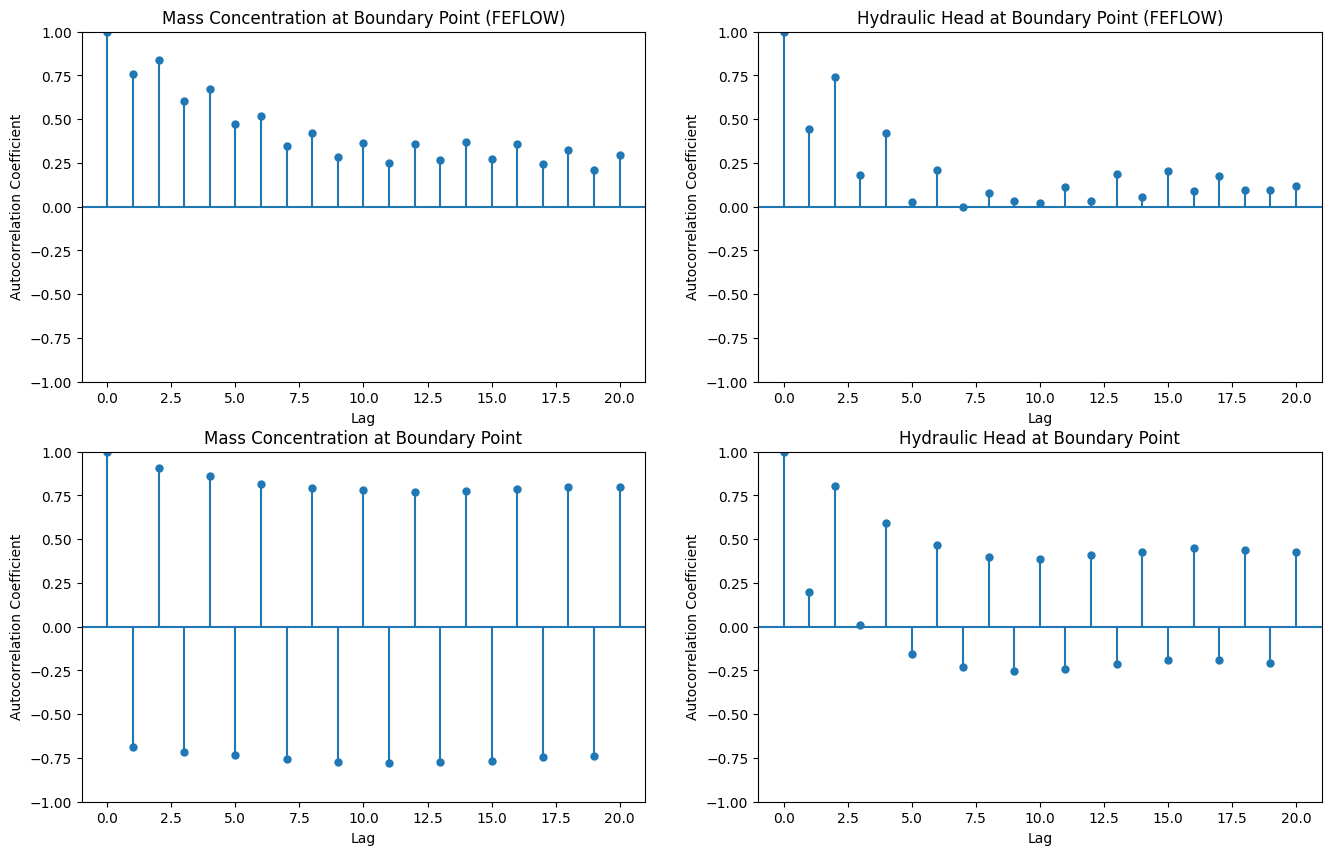

In [44]:

# Boundary Point

# ## Green
# x = 0.8052106
# y = -0.2139706
# z = -0.5713595

## Yellow
x = -0.8988321
y = 0.2453935
z = 0.399271

# ## Violet
# x = 0.3365833
# y = 0.3270847
# z = 0.4767448

# Point
value = np.array([x, y, z])

# Closest point index
point_index = (np.square(coords - value).sum(axis=-1)).argmin()
point_index, value


# Figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plot_acf(mass_conc_targets[point_index], lags=20, ax=axes[0, 0], title="Mass Concentration at Boundary Point (FEFLOW)", bartlett_confint=False, alpha=None)
axes[0, 0].set_xlabel("Lag")
axes[0, 0].set_ylabel("Autocorrelation Coefficient")

plot_acf(hydraulic_head_targets[point_index], lags=20, ax=axes[0, 1], title="Hydraulic Head at Boundary Point (FEFLOW)", bartlett_confint=False, alpha=None)
axes[0, 1].set_xlabel("Lag")
axes[0, 1].set_ylabel("Autocorrelation Coefficient")

plot_acf(mass_conc_preds[point_index], lags=20, ax=axes[1, 0], title="Mass Concentration at Boundary Point", bartlett_confint=False, alpha=None)
axes[1, 0].set_xlabel("Lag")
axes[1, 0].set_ylabel("Autocorrelation Coefficient")

plot_acf(hydraulic_head_preds[point_index], lags=20, ax=axes[1, 1], title="Hydraulic Head at Boundary Point", bartlett_confint=False, alpha=None)
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Autocorrelation Coefficient")

# fig.savefig('figures/fno_boundary_point_autocorr.png', bbox_inches='tight')

Text(0, 0.5, 'Autocorrelation Coefficient')

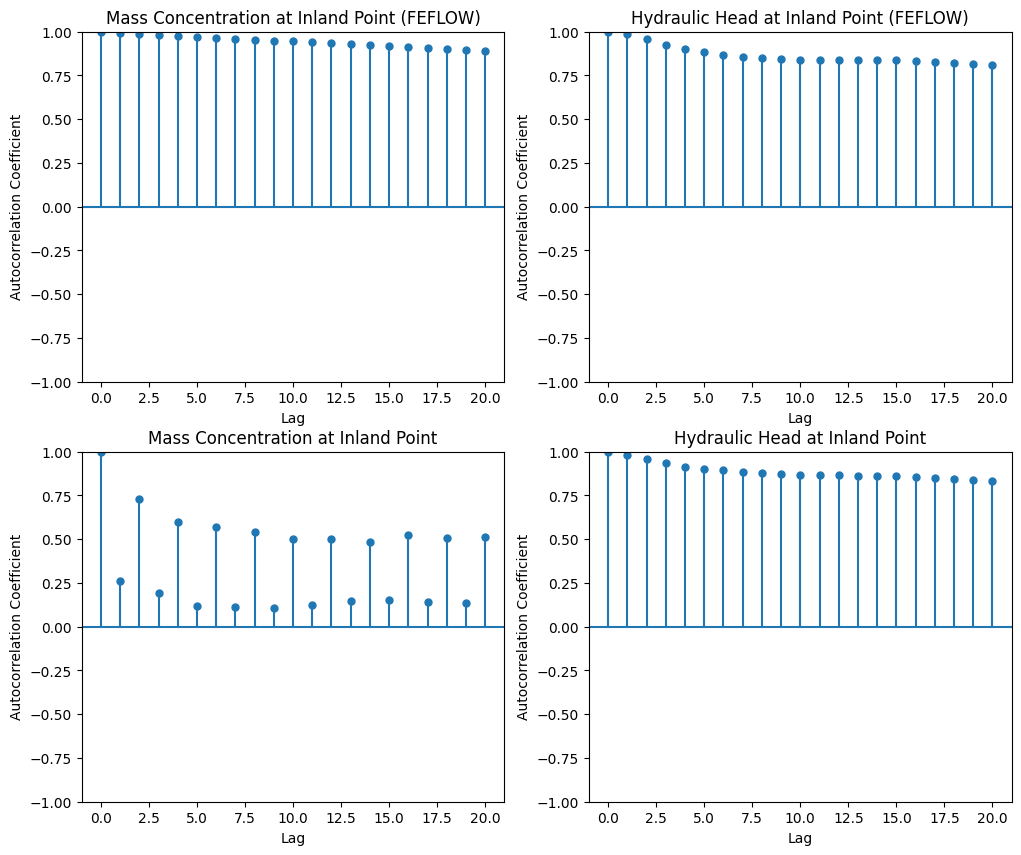

In [43]:
# Inland Point
x = 0.5144902
y = 0.3351829
z = 1.066303

# Point
value = np.array([x, y, z])

# Closest point index
point_index = (np.square(coords - value).sum(axis=-1)).argmin()

# Figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_acf(mass_conc_targets[point_index], lags=20, ax=axes[0, 0], title="Mass Concentration at Inland Point (FEFLOW)", bartlett_confint=False, alpha=None)
axes[0, 0].set_xlabel("Lag")
axes[0, 0].set_ylabel("Autocorrelation Coefficient")

plot_acf(hydraulic_head_targets[point_index], lags=20, ax=axes[0, 1], title="Hydraulic Head at Inland Point (FEFLOW)", bartlett_confint=False, alpha=None)
axes[0, 1].set_xlabel("Lag")
axes[0, 1].set_ylabel("Autocorrelation Coefficient")

plot_acf(mass_conc_preds[point_index], lags=20, ax=axes[1, 0], title="Mass Concentration at Inland Point", bartlett_confint=False, alpha=None)
axes[1, 0].set_xlabel("Lag")
axes[1, 0].set_ylabel("Autocorrelation Coefficient")

plot_acf(hydraulic_head_preds[point_index], lags=20, ax=axes[1, 1], title="Hydraulic Head at Inland Point", bartlett_confint=False, alpha=None)
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Autocorrelation Coefficient")

# fig.savefig('figures/inland_point_autocorr.png', bbox_inches='tight')

In [20]:
# Boundary Points

## Green
x = 0.8052106
y = -0.2139706
z = -0.5713595
g_boundary = np.array([x, y, z])
g_boundary = (np.square(coords - g_boundary).sum(axis=-1)).argmin()

## Yellow
x = -0.8988321
y = 0.2453935
z = 0.399271
y_boundary = np.array([x, y, z])
y_boundary = (np.square(coords - y_boundary).sum(axis=-1)).argmin()

## Violet
x = 0.3365833
y = 0.3270847
z = 0.4767448
v_boundary = np.array([x, y, z])
v_boundary = (np.square(coords - v_boundary).sum(axis=-1)).argmin()


# Inland Points
# p1
x = 0.5144902
y = 0.3351829
z = 1.066303
p1_inland = np.array([x, y, z])
p1_inland = (np.square(coords - p1_inland).sum(axis=-1)).argmin()

# p2
x = 0.1995796
y = -0.5030094
z = 0.7387709
p2_inland = np.array([x, y, z])
p2_inland = (np.square(coords - p2_inland).sum(axis=-1)).argmin()


df_points = pd.DataFrame({'g_boundary': mass_conc_preds[g_boundary], 
              'y_boundary': mass_conc_preds[y_boundary],
              'v_boundary': mass_conc_preds[v_boundary],
              'p1_inland': mass_conc_preds[p1_inland],
              'p2_inland': mass_conc_preds[p2_inland]})



corr = df_points.corr()
corr.style.background_gradient(cmap='coolwarm')

,g_boundary,y_boundary,v_boundary,p1_inland,p2_inland
g_boundary,1.000000,0.005533,0.357030,0.712670,0.352588
y_boundary,0.005533,1.000000,0.015813,-0.070363,-0.152674
v_boundary,0.357030,0.015813,1.000000,0.364164,0.414004
p1_inland,0.712670,-0.070363,0.364164,1.000000,0.281935
p2_inland,0.352588,-0.152674,0.414004,0.281935,1.000000


In [21]:
df_points = pd.DataFrame({'g_boundary': mass_conc_targets[g_boundary], 
              'y_boundary': mass_conc_targets[y_boundary],
              'v_boundary': mass_conc_targets[v_boundary],
              'p1_inland': mass_conc_targets[p1_inland],
              'p2_inland': mass_conc_targets[p2_inland]})



corr = df_points.corr()
corr.style.background_gradient(cmap='coolwarm')

,g_boundary,y_boundary,v_boundary,p1_inland,p2_inland
g_boundary,1.000000,0.145224,-0.027454,0.708126,-0.518033
y_boundary,0.145224,1.000000,0.351316,-0.056446,0.175361
v_boundary,-0.027454,0.351316,1.000000,-0.592309,0.812352
p1_inland,0.708126,-0.056446,-0.592309,1.000000,-0.950658
p2_inland,-0.518033,0.175361,0.812352,-0.950658,1.000000
